# IMPORTS

In [4]:
from pathlib import Path
import pandas as pd
from diive.core.io.files import save_parquet, load_parquet

# LOAD DATA

In [5]:
nee = load_parquet(filepath=r"81_NEE/81.7.1_NEE_GF-XGBoost_GPP_RECO.parquet")
n2o = load_parquet(filepath=r"82_FN2O/82.4.1_FN2O_GF-XGBoost.parquet")
ch4 = load_parquet(filepath=r"83_FCH4/83.4.1_FCH4_GF-XGBoost.parquet")

Loaded .parquet file 81_NEE/81.7.1_NEE_GF-XGBoost_GPP_RECO.parquet (0.177 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file 82_FN2O/82.4.1_FN2O_GF-XGBoost.parquet (0.102 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file 83_FCH4/83.4.1_FCH4_GF-XGBoost.parquet (0.164 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


# MERGE

,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,RECO_NT_CUT_50_gfXG_parcelA_all,GPP_NT_CUT_50_gfXG_parcelA_all,RECO_NT_CUT_50_gfXG_parcelA_certain,GPP_NT_CUT_50_gfXG_parcelA_certain,RECO_NT_CUT_50_gfXG_parcelB_all,GPP_NT_CUT_50_gfXG_parcelB_all,RECO_NT_CUT_50_gfXG_parcelB_certain,GPP_NT_CUT_50_gfXG_parcelB_certain,FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain,FCH4_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all,FCH4_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain,FCH4_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all,FCH4_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,
2023-11-07 23:15:00,NaN,NaN,NaN,NaN,1.498848,-0.070040,1.498848,-0.070040,1.498848,-0.070040,1.498848,-0.070040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-07 23:45:00,NaN,NaN,NaN,NaN,1.497579,-0.066121,1.497579,-0.066121,1.497579,-0.066121,1.497579,-0.066121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-08 00:15:00,2.339872,2.339872,2.339872,2.339872,1.496309,-0.843563,1.496309,-0.843563,1.496309,-0.843563,1.496309,-0.843563,1.307995,1.307995,1.175743,1.175743,10.612315,10.612315,-3.231648,-3.231648
2023-11-08 00:45:00,2.411913,2.411913,2.411913,2.411913,1.520340,-0.891574,1.520340,-0.891574,1.520340,-0.891574,1.520340,-0.891574,1.357496,1.357496,0.100302,0.100302,10.612315,10.612315,5.978182,5.978182
2023-11-08 01:15:00,2.129587,2.129587,2.129587,2.129587,1.515298,-0.614290,1.515298,-0.614290,1.515298,-0.614290,1.515298,-0.614290,1.061260,1.061260,0.239428,0.239428,10.612315,10.612315,5.978182,5.978182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,7.216800,7.216800,7.216800,7.216800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.591581,1.591581,1.620675,1.620675,5.229702,5.229702,9.629095,9.629095
2025-06-05 22:15:00,7.237069,7.237069,7.237069,7.237069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.660556,1.660556,1.691179,1.691179,5.229702,5.229702,9.629095,9.629095
2025-06-05 22:45:00,8.158186,8.158186,8.158186,8.158186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.647371,1.647371,1.677905,1.677905,5.229702,5.229702,9.629095,9.629095


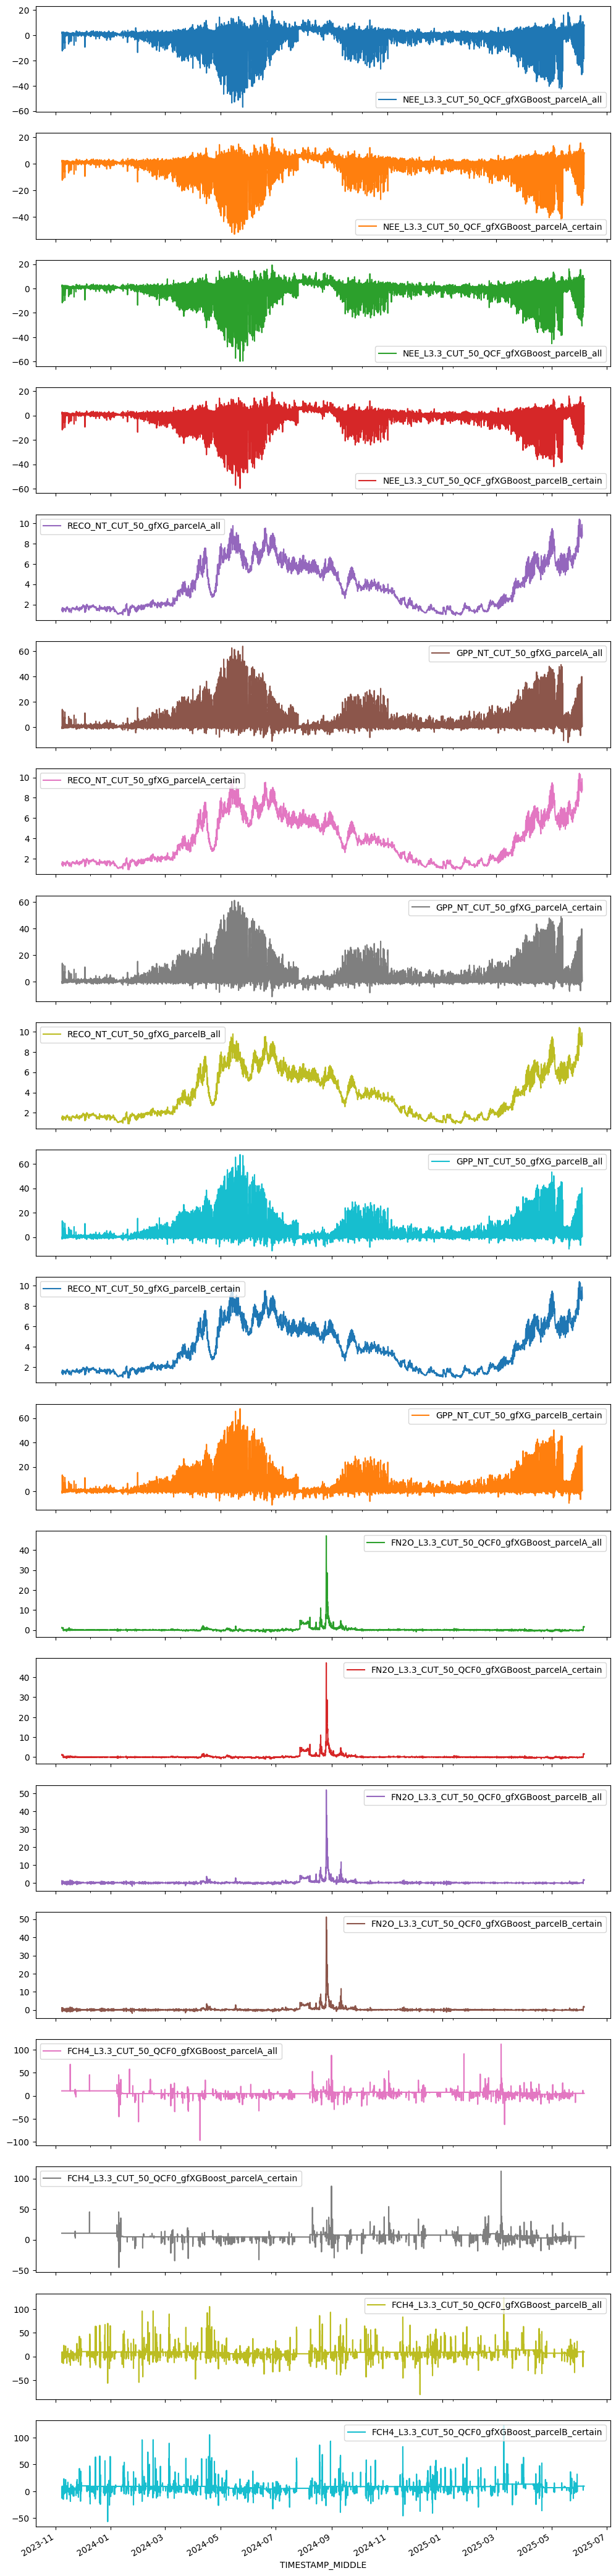

In [6]:
df = pd.concat([nee, n2o, ch4], axis=1)
df.plot(x_compat=True, subplots=True, figsize=(12, len(df.columns)*3));
df

# EXPORT

In [7]:
filename = "84.1_GF-FLUXES+PARTITIONED"
df.to_csv(f"{filename}.csv", index=True)
save_parquet(data=df, filename=filename)

Saved file 84.1_GF-FLUXES+PARTITIONED.parquet (0.197 seconds).


'84.1_GF-FLUXES+PARTITIONED.parquet'

# **End of notebook**

In [8]:
from datetime import datetime
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-14 14:54:42
